# Mixed PINN for 2D linear elastostatics with scaling

The goal is to simultaneously approximate two displacement components and three components of the symmetric stress tensor on the domain

$$
\Omega=(0,1)^2.
$$

The network operates with scaled coordinates and outputs

$$
\widehat{\mathbf q}_\theta(\widehat x,\widehat y)
=
\begin{bmatrix}
\widehat u_{1,\theta} & \widehat u_{2,\theta} &
\widehat\sigma_{xx,\theta} & \widehat\sigma_{yy,\theta} &
\widehat\sigma_{xy,\theta}
\end{bmatrix}^{\mathsf T}.
$$

The exact displacement is

$$
\mathbf u_{\mathrm{exact}}(x,y)
=a
\begin{bmatrix}
\cos x-y^2\\
2\sin x+y
\end{bmatrix},
\qquad a=0.005.
$$

The material parameters are

$$
E=10^{10},
\qquad \nu=\frac14,
\qquad \lambda=\mu=\frac{2E}{5}=4\cdot10^9.
$$

## Reference quantities

We use the scaling

$$
\mathbf x=L_{\mathrm{ref}}\widehat{\mathbf x},
\qquad
\mathbf u=U_{\mathrm{ref}}\widehat{\mathbf u},
$$

where

$$
L_{\mathrm{ref}}=\operatorname{diam}(\Omega)=\sqrt2
$$

a

$$
U_{\mathrm{ref}}
=\max_{\Gamma_D}\|\mathbf u_{\mathrm{exact}}\|_2
=a\sqrt{(\cos1-1)^2+(2\sin1+1)^2}.
$$

The maximum on the Dirichlet part of the boundary occurs at the point $(1,1)$. We further define

$$
\varepsilon_{\mathrm{ref}}=\frac{U_{\mathrm{ref}}}{L_{\mathrm{ref}}},
\qquad
\sigma_{\mathrm{ref}}=E\frac{U_{\mathrm{ref}}}{L_{\mathrm{ref}}},
$$

$$
b_{\mathrm{ref}}=E\frac{U_{\mathrm{ref}}}{L_{\mathrm{ref}}^2},
\qquad
t_{\mathrm{ref}}=\sigma_{\mathrm{ref}}.
$$

The scaled domain is

$$
\widehat\Omega=\left(0,\frac1{\sqrt2}\right)^2.
$$

## Scaled strong form

For

$$
\widehat{\boldsymbol\varepsilon}
=\frac12\left(
\nabla_{\widehat{\mathbf x}}\widehat{\mathbf u}
+\nabla_{\widehat{\mathbf x}}\widehat{\mathbf u}^{\mathsf T}
\right)
$$

we have

$$
\widehat{\boldsymbol\sigma}
=\frac{\lambda}{E}
\operatorname{tr}(\widehat{\boldsymbol\varepsilon})\mathbf I
+2\frac{\mu}{E}\widehat{\boldsymbol\varepsilon},
$$

$$
\nabla_{\widehat{\mathbf x}}\cdot\widehat{\boldsymbol\sigma}
+\widehat{\mathbf b}=\mathbf0,
\qquad
\widehat{\mathbf b}=\frac{\mathbf b}{b_{\mathrm{ref}}}.
$$

Since $\lambda/E=\mu/E=2/5$, the magnitude of Young's modulus does not appear in the scaled residuals. On $\Gamma_D$, we use $\widehat{\mathbf u}_D=\mathbf u_D/U_{\mathrm{ref}}$, and on $\Gamma_N$, the scaled traction $\widehat{\mathbf t}=\mathbf t/t_{\mathrm{ref}}$.

## 1. Library imports


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


/home/eliska/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Parameters and reference quantities

- `USE_DATA = False`: pure mixed PINN.
- `USE_DATA = True`: adds a loss term for known scaled values of all five fields.
- The first 1900 epochs use Adam and the final 100 epochs use L-BFGS.
- The network takes $(\widehat x,\widehat y)$ as input and returns $(\widehat{\mathbf u},\widehat{\boldsymbol\sigma})$.

In [4]:
USE_DATA = True

E = 1.0e10
NU = 1.0 / 4.0
AMPLITUDE = 0.005

# Lame constants.
LAMBDA = E * NU / ((1.0 + NU) * (1.0 - 2.0 * NU))
MU = E / (2.0 * (1.0 + NU))

# Chosen reference quantities.
L_REF = np.sqrt(2.0)
U_REF = AMPLITUDE * np.sqrt((np.cos(1.0) - 1.0) ** 2 + (2.0 * np.sin(1.0) + 1.0) ** 2)
EPS_REF = U_REF / L_REF
STRESS_REF = E * U_REF / L_REF
BODY_FORCE_REF = STRESS_REF / L_REF
TRACTION_REF = STRESS_REF

# Dimensionless material constants and the size of the scaled domain.
LAMBDA_SCALED = LAMBDA / E
MU_SCALED = MU / E
DOMAIN_MAX_SCALED = 1.0 / L_REF

N_PDE_TRAIN = 2000
N_PDE_VALIDATION = 1000
N_PDE_TEST = 2000
PDE_BATCH_SIZE = 64
N_BOUNDARY_PER_EDGE = 100
N_DATA_TRAIN = 70
N_DATA_VALIDATION = 20
N_DATA_TEST = 20

EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)

E_FROM_LAME = MU * (3.0 * LAMBDA + 2.0 * MU) / (LAMBDA + MU)
NU_FROM_LAME = LAMBDA / (2.0 * (LAMBDA + MU))


## 3. Exact and scaled quantities

Functions with the `_real` suffix return values in the original units. Functions with the `_scaled` suffix take scaled coordinates and return the scaled quantities used in the loss.

In [5]:
def to_real_coordinates(xy_scaled):
    'Transformation x = L_ref * x_hat.'
    return L_REF * xy_scaled


def exact_displacement_real(xy_real):
    'Exact displacement [u1, u2].'
    x = xy_real[:, 0:1]
    y = xy_real[:, 1:2]

    u1 = AMPLITUDE * (torch.cos(x) - y**2)
    u2 = AMPLITUDE * (2.0 * torch.sin(x) + y)
    return torch.cat((u1, u2), dim=1)


def exact_stress_real(xy_real):
    'Exact stress components [sigma_xx, sigma_yy, sigma_xy].'
    x = xy_real[:, 0:1]
    y = xy_real[:, 1:2]
    a = AMPLITUDE

    eps_xx = -a * torch.sin(x)
    eps_yy = a * torch.ones_like(x)
    eps_xy = a * (torch.cos(x) - y)
    trace_eps = eps_xx + eps_yy

    sigma_xx = LAMBDA * trace_eps + 2.0 * MU * eps_xx
    sigma_yy = LAMBDA * trace_eps + 2.0 * MU * eps_yy
    sigma_xy = 2.0 * MU * eps_xy
    return torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)


def body_force_real(xy_real):
    'Exact body force b = -div(sigma_exact).'
    x = xy_real[:, 0:1]
    a = AMPLITUDE

    b1 = a * (LAMBDA + 2.0 * MU) * torch.cos(x) + 2.0 * MU * a
    b2 = 2.0 * MU * a * torch.sin(x)
    return torch.cat((b1, b2), dim=1)


def exact_displacement_scaled(xy_scaled):
    xy_real = to_real_coordinates(xy_scaled)
    return exact_displacement_real(xy_real) / U_REF


def exact_stress_scaled(xy_scaled):
    xy_real = to_real_coordinates(xy_scaled)
    return exact_stress_real(xy_real) / STRESS_REF


def exact_fields_scaled(xy_scaled):
    return torch.cat((exact_displacement_scaled(xy_scaled), exact_stress_scaled(xy_scaled)), dim=1,)


def body_force_scaled(xy_scaled):
    xy_real = to_real_coordinates(xy_scaled)
    return body_force_real(xy_real) / BODY_FORCE_REF


def exact_traction_scaled(xy_scaled, normals):
    stress_scaled = exact_stress_scaled(xy_scaled)
    sigma_xx = stress_scaled[:, 0:1]
    sigma_yy = stress_scaled[:, 1:2]
    sigma_xy = stress_scaled[:, 2:3]

    nx = normals[:, 0:1]
    ny = normals[:, 1:2]

    traction_x = sigma_xx * nx + sigma_xy * ny
    traction_y = sigma_xy * nx + sigma_yy * ny
    return torch.cat((traction_x, traction_y), dim=1)


def scaled_fields_to_real(fields_scaled):
    'Convert the five scaled fields back to the original units.'
    displacement = U_REF * fields_scaled[:, 0:2]
    stress = STRESS_REF * fields_scaled[:, 2:5]
    return torch.cat((displacement, stress), dim=1)

## 4. Neural network with five scaled outputs

The network outputs are ordered as

$$
[\widehat u_{1,\theta},\widehat u_{2,\theta},
\widehat\sigma_{xx,\theta},\widehat\sigma_{yy,\theta},
\widehat\sigma_{xy,\theta}].
$$

In [6]:
class MixedPINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 5),
        )

    def forward(self, xy):
        return self.net(xy)


model = MixedPINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)


## 5. Training, validation, test, and boundary points

Validation points are fixed and are not used by either optimizer.


In [7]:
pde_train_generator = torch.Generator().manual_seed(SEED + 1)
xy_pde_train = DOMAIN_MAX_SCALED * torch.rand(N_PDE_TRAIN, 2, generator=pde_train_generator)
pde_dataset = TensorDataset(xy_pde_train)
pde_batch_generator = torch.Generator().manual_seed(SEED + 5)
pde_loader = DataLoader(pde_dataset, batch_size=PDE_BATCH_SIZE, shuffle=True, generator=pde_batch_generator)

pde_validation_generator = torch.Generator().manual_seed(SEED + 10)
xy_pde_validation = DOMAIN_MAX_SCALED * torch.rand(N_PDE_VALIDATION, 2, generator=pde_validation_generator)
xy_pde_validation.requires_grad_(True)

pde_test_generator = torch.Generator().manual_seed(SEED + 2)
xy_pde_test = DOMAIN_MAX_SCALED * torch.rand(N_PDE_TEST, 2, generator=pde_test_generator)
xy_pde_test.requires_grad_(True)

t_scaled = torch.linspace(0.0, DOMAIN_MAX_SCALED, N_BOUNDARY_PER_EDGE).view(-1, 1)
left = torch.cat((torch.zeros_like(t_scaled), t_scaled), dim=1)
right = torch.cat((DOMAIN_MAX_SCALED * torch.ones_like(t_scaled), t_scaled), dim=1)
xy_dirichlet = torch.cat((left, right), dim=0)
u_dirichlet_scaled = exact_displacement_scaled(xy_dirichlet)
bottom = torch.cat((t_scaled, torch.zeros_like(t_scaled)), dim=1)
top = torch.cat((t_scaled, DOMAIN_MAX_SCALED * torch.ones_like(t_scaled)), dim=1)
normal_bottom = torch.cat((torch.zeros_like(t_scaled), -torch.ones_like(t_scaled)), dim=1)
normal_top = torch.cat((torch.zeros_like(t_scaled), torch.ones_like(t_scaled)), dim=1)
xy_neumann = torch.cat((bottom, top), dim=0)
normals_neumann = torch.cat((normal_bottom, normal_top), dim=0)
traction_neumann_scaled = exact_traction_scaled(xy_neumann, normals_neumann)

if USE_DATA:
    data_train_generator = torch.Generator().manual_seed(SEED + 3)
    xy_data_train = DOMAIN_MAX_SCALED * torch.rand(N_DATA_TRAIN, 2, generator=data_train_generator)
    fields_data_train_scaled = exact_fields_scaled(xy_data_train)
    data_validation_generator = torch.Generator().manual_seed(SEED + 11)
    xy_data_validation = DOMAIN_MAX_SCALED * torch.rand(N_DATA_VALIDATION, 2, generator=data_validation_generator)
    fields_data_validation_scaled = exact_fields_scaled(xy_data_validation)
    data_test_generator = torch.Generator().manual_seed(SEED + 4)
    xy_data_test = DOMAIN_MAX_SCALED * torch.rand(N_DATA_TEST, 2, generator=data_test_generator)
    fields_data_test_scaled = exact_fields_scaled(xy_data_test)


## 6. Scaled equilibrium and constitutive residuals

Because the network predicts the scaled stress independently, the physics loss contains two parts. The equilibrium residual is

$$
\widehat{\mathbf r}_{\mathrm{eq},\theta}
=\nabla_{\widehat{\mathbf x}}\cdot
\widehat{\boldsymbol\sigma}_\theta+\widehat{\mathbf b}.
$$

The constitutive residual is

$$
\widehat{\mathbf r}_{\mathrm{const},\theta}
=\widehat{\boldsymbol\sigma}_\theta-
\left[
\frac{\lambda}{E}
\operatorname{tr}(\widehat{\boldsymbol\varepsilon})\mathbf I
+2\frac{\mu}{E}\widehat{\boldsymbol\varepsilon}
\right].
$$

The total scaled loss is

$$
\mathcal L=\mathcal L_{\mathrm{eq}}
+\mathcal L_{\mathrm{const}}
+\mathcal L_{\mathrm D}
+\mathcal L_{\mathrm N}
+\mathcal L_{\mathrm{data}}.
$$

All terms compare quantities of order one. For `USE_DATA = False`, $\mathcal L_{\mathrm{data}}=0$.

In [8]:
def split_prediction(prediction_scaled):
    u1_scaled = prediction_scaled[:, 0:1]
    u2_scaled = prediction_scaled[:, 1:2]
    sigma_xx_scaled = prediction_scaled[:, 2:3]
    sigma_yy_scaled = prediction_scaled[:, 3:4]
    sigma_xy_scaled = prediction_scaled[:, 4:5]
    return (u1_scaled, u2_scaled, sigma_xx_scaled, sigma_yy_scaled, sigma_xy_scaled,)


def constitutive_stress_from_displacement_scaled(xy_scaled, u1_scaled, u2_scaled, create_graph,):
    'Returns sigma_hat from the gradient of u_hat with respect to x_hat.'
    grad_u1_scaled = torch.autograd.grad(u1_scaled, xy_scaled, grad_outputs=torch.ones_like(u1_scaled), create_graph=create_graph, retain_graph=True,)[0]
    grad_u2_scaled = torch.autograd.grad(u2_scaled, xy_scaled, grad_outputs=torch.ones_like(u2_scaled), create_graph=create_graph, retain_graph=True,)[0]

    eps_xx_scaled = grad_u1_scaled[:, 0:1]
    eps_yy_scaled = grad_u2_scaled[:, 1:2]
    eps_xy_scaled = 0.5 * (grad_u1_scaled[:, 1:2] + grad_u2_scaled[:, 0:1])
    trace_eps_scaled = eps_xx_scaled + eps_yy_scaled

    sigma_xx_scaled = (LAMBDA_SCALED * trace_eps_scaled + 2.0 * MU_SCALED * eps_xx_scaled)
    sigma_yy_scaled = (LAMBDA_SCALED * trace_eps_scaled + 2.0 * MU_SCALED * eps_yy_scaled)
    sigma_xy_scaled = 2.0 * MU_SCALED * eps_xy_scaled
    return torch.cat((sigma_xx_scaled, sigma_yy_scaled, sigma_xy_scaled), dim=1)


def mixed_residuals(xy_scaled, training=True):
    prediction_scaled = model(xy_scaled)
    values = split_prediction(prediction_scaled)
    u1_scaled, u2_scaled = values[0], values[1]
    sigma_xx_scaled, sigma_yy_scaled, sigma_xy_scaled = values[2:]

    constitutive_stress_scaled = (constitutive_stress_from_displacement_scaled(xy_scaled, u1_scaled, u2_scaled, create_graph=training))
    predicted_stress_scaled = torch.cat((sigma_xx_scaled, sigma_yy_scaled, sigma_xy_scaled), dim=1)
    residual_constitutive_scaled = (predicted_stress_scaled - constitutive_stress_scaled)

    grad_sigma_xx_scaled = torch.autograd.grad(sigma_xx_scaled, xy_scaled, grad_outputs=torch.ones_like(sigma_xx_scaled), create_graph=training, retain_graph=True)[0]
    grad_sigma_yy_scaled = torch.autograd.grad(sigma_yy_scaled, xy_scaled, grad_outputs=torch.ones_like(sigma_yy_scaled), create_graph=training, retain_graph=True)[0]
    grad_sigma_xy_scaled = torch.autograd.grad(sigma_xy_scaled, xy_scaled, grad_outputs=torch.ones_like(sigma_xy_scaled), create_graph=training, retain_graph=True)[0]

    b_scaled = body_force_scaled(xy_scaled)
    residual_1_scaled = (grad_sigma_xx_scaled[:, 0:1] + grad_sigma_xy_scaled[:, 1:2] + b_scaled[:, 0:1])
    residual_2_scaled = (grad_sigma_xy_scaled[:, 0:1] + grad_sigma_yy_scaled[:, 1:2] + b_scaled[:, 1:2])
    residual_equilibrium_scaled = torch.cat((residual_1_scaled, residual_2_scaled), dim=1)

    return (residual_equilibrium_scaled, residual_constitutive_scaled, prediction_scaled)


def compute_losses(xy_pde):
    xy_pde = xy_pde.requires_grad_(True)
    residual_eq, residual_const, _ = mixed_residuals(xy_pde, training=True,)
    loss_equilibrium = torch.mean(residual_eq**2)
    loss_constitutive = torch.mean(residual_const**2)

    dirichlet_prediction_scaled = model(xy_dirichlet)[:, 0:2]
    loss_dirichlet = torch.mean((dirichlet_prediction_scaled - u_dirichlet_scaled) ** 2)

    neumann_prediction_scaled = model(xy_neumann)
    values = split_prediction(neumann_prediction_scaled)
    sigma_xx_scaled, sigma_yy_scaled, sigma_xy_scaled = values[2:]
    nx = normals_neumann[:, 0:1]
    ny = normals_neumann[:, 1:2]
    traction_x_scaled = sigma_xx_scaled * nx + sigma_xy_scaled * ny
    traction_y_scaled = sigma_xy_scaled * nx + sigma_yy_scaled * ny
    traction_prediction_scaled = torch.cat((traction_x_scaled, traction_y_scaled), dim=1)
    loss_neumann = torch.mean((traction_prediction_scaled - traction_neumann_scaled) ** 2)
    loss_boundary = loss_dirichlet + loss_neumann

    if USE_DATA:
        data_prediction_scaled = model(xy_data_train)
        loss_data = torch.mean((data_prediction_scaled - fields_data_train_scaled) ** 2)
    else:
        loss_data = torch.tensor(0.0)

    loss = (loss_equilibrium + loss_constitutive + loss_boundary + loss_data)

    return (loss, loss_equilibrium, loss_constitutive, loss_boundary, loss_data)


def compute_validation_losses():
    residual_eq, residual_const, _ = mixed_residuals(xy_pde_validation, training=False)
    loss_validation_equilibrium = torch.mean(residual_eq.detach()**2)
    loss_validation_constitutive = torch.mean(residual_const.detach()**2)
    with torch.no_grad():
        loss_validation_data = torch.mean((model(xy_data_validation) - fields_data_validation_scaled)**2) if USE_DATA else loss_validation_equilibrium.new_tensor(0.0)
    loss_validation = loss_validation_equilibrium + loss_validation_constitutive + loss_validation_data
    return loss_validation, loss_validation_equilibrium, loss_validation_constitutive, loss_validation_data


## 7. Training, validation, and best-epoch selection


In [9]:
loss_history, equilibrium_loss_history, constitutive_loss_history = [], [], []
boundary_loss_history, data_loss_history = [], []
validation_loss_history, validation_equilibrium_loss_history = [], []
validation_constitutive_loss_history, validation_data_loss_history = [], []
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
best_validation_loss = float("inf")
best_validation_equilibrium_loss = None
best_validation_constitutive_loss = None
best_validation_data_loss = None
best_epoch = None
best_model_state = None

def clone_model_state():
    return {name: value.detach().clone() for name, value in model.state_dict().items()}

def update_validation_checkpoint(epoch):
    global best_validation_loss, best_validation_equilibrium_loss, best_validation_constitutive_loss, best_validation_data_loss, best_epoch, best_model_state
    validation, validation_eq, validation_const, validation_data = compute_validation_losses()
    values = validation.item(), validation_eq.item(), validation_const.item(), validation_data.item()
    validation_loss_history.append(values[0])
    validation_equilibrium_loss_history.append(values[1])
    validation_constitutive_loss_history.append(values[2])
    validation_data_loss_history.append(values[3])
    if best_model_state is None or values[0] < best_validation_loss:
        best_validation_loss, best_validation_equilibrium_loss, best_validation_constitutive_loss, best_validation_data_loss = values
        best_epoch = epoch
        best_model_state = clone_model_state()
    return values[0]

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, mode="min", factor=0.5, patience=200)

for epoch in range(ADAM_EPOCHS):
    epoch_sums = np.zeros(5)
    for (xy_pde_batch,) in pde_loader:
        optimizer_adam.zero_grad()
        losses = compute_losses(xy_pde_batch)
        losses[0].backward()
        optimizer_adam.step()
        epoch_sums += np.array([value.detach().item() for value in losses])
    values = epoch_sums / len(pde_loader)
    loss_value, eq_value, const_value, bc_value, data_value = values
    scheduler.step(loss_value)
    loss_history.append(loss_value)
    equilibrium_loss_history.append(eq_value)
    constitutive_loss_history.append(const_value)
    boundary_loss_history.append(bc_value)
    data_loss_history.append(data_value)
    validation_value = update_validation_checkpoint(epoch)
    if epoch % 500 == 0:
        print(f"Adam | epoch {epoch:5d} | loss={loss_value:.6e} | eq={eq_value:.6e} | const={const_value:.6e} | BC={bc_value:.6e} | data={data_value:.6e} | validation={validation_value:.6e}")

print(f"Switching from Adam to L-BFGS at epoch {ADAM_EPOCHS}.")
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=10, line_search_fn="strong_wolfe")

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch
    def closure():
        optimizer_lbfgs.zero_grad()
        xy_pde_train.grad = None
        loss = compute_losses(xy_pde_train)[0]
        loss.backward()
        return loss
    optimizer_lbfgs.step(closure)
    loss, loss_eq, loss_const, loss_bc, loss_data = compute_losses(xy_pde_train)
    loss_history.append(loss.detach().item())
    equilibrium_loss_history.append(loss_eq.detach().item())
    constitutive_loss_history.append(loss_const.detach().item())
    boundary_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())
    validation_value = update_validation_checkpoint(epoch)
    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(f"L-BFGS | epoch {epoch:5d} | loss={loss.item():.6e} | eq={loss_eq.item():.6e} | const={loss_const.item():.6e} | BC={loss_bc.item():.6e} | data={loss_data.item():.6e} | validation={validation_value:.6e}")

last_model_state = clone_model_state()
model.load_state_dict(best_model_state)
model.eval()
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_validation_loss:.6e}")


Adam | epoch     0 | loss=1.057375e+00 | eq=6.878742e-01 | const=4.537234e-02 | BC=2.389286e-01 | data=8.519995e-02 | validation=3.979030e-01
Adam | epoch   500 | loss=1.822177e-05 | eq=1.732137e-06 | const=1.365563e-05 | BC=1.833767e-06 | data=1.000231e-06 | validation=5.662840e-06
Adam | epoch  1000 | loss=1.581112e-06 | eq=3.515558e-07 | const=7.815966e-07 | BC=2.900377e-07 | data=1.579216e-07 | validation=1.698861e-06
Adam | epoch  1500 | loss=4.746706e-07 | eq=1.196980e-07 | const=2.274496e-07 | BC=8.170477e-08 | data=4.581827e-08 | validation=3.699129e-07
Switching from Adam to L-BFGS at epoch 1900.
L-BFGS | epoch  1900 | loss=2.529726e-07 | eq=7.424205e-08 | const=1.274638e-07 | BC=3.292207e-08 | data=1.834462e-08 | validation=2.463213e-07
L-BFGS | epoch  1950 | loss=2.465777e-07 | eq=7.225697e-08 | const=1.235653e-07 | BC=3.278310e-08 | data=1.797234e-08 | validation=2.382241e-07
L-BFGS | epoch  1999 | loss=2.465777e-07 | eq=7.225697e-08 | const=1.235653e-07 | BC=3.278310e-08 |

## 8. Testing the restored best model on independent points


In [10]:
model.eval()
xy_pde_test.grad = None
residual_eq_test, residual_const_test, prediction_test_scaled = mixed_residuals(xy_pde_test, training=False)
exact_test_scaled = exact_fields_scaled(xy_pde_test).detach()
prediction_test = scaled_fields_to_real(prediction_test_scaled)
exact_test = scaled_fields_to_real(exact_test_scaled)
u_prediction, u_exact = prediction_test[:, 0:2], exact_test[:, 0:2]
stress_prediction, stress_exact = prediction_test[:, 2:5], exact_test[:, 2:5]

def r2_score(prediction, exact):
    ss_res = torch.sum((prediction - exact)**2)
    ss_tot = torch.sum((exact - torch.mean(exact))**2)
    return (1.0 - ss_res / ss_tot).item()

def relative_l2(prediction, exact):
    return (torch.linalg.vector_norm(prediction - exact) / torch.linalg.vector_norm(exact)).item()

r2_u = r2_score(u_prediction, u_exact)
relative_l2_u = relative_l2(u_prediction, u_exact)
r2_stress = r2_score(stress_prediction, stress_exact)
relative_l2_stress = relative_l2(stress_prediction, stress_exact)
metrics = {"best_epoch": best_epoch, "best_validation_loss": best_validation_loss, "R2_displacement": r2_u, "relative_L2_displacement": relative_l2_u, "R2_stress": r2_stress, "relative_L2_stress": relative_l2_stress}

print("=" * 72)
print("TEST RESULTS OF THE RESTORED BEST SCALED MIXED 2D PINN")
print("=" * 72)
print(f"Best epoch:                         {best_epoch}")
print(f"R2 displacement:                    {r2_u:.8f}")
print(f"Relative L2 displacement error:     {relative_l2_u:.6e}")
print(f"R2 stress:                          {r2_stress:.8f}")
print(f"Relative L2 stress error:           {relative_l2_stress:.6e}")
print("=" * 72)
metrics


TEST RESULTS OF THE RESTORED BEST SCALED MIXED 2D PINN
Best epoch:                         1905
R2 displacement:                    0.99999994
Relative L2 displacement error:     1.157138e-04
R2 stress:                          0.99999952
Relative L2 stress error:           5.832377e-04


{'best_epoch': 1905,
 'best_validation_loss': 2.3822408934393025e-07,
 'R2_displacement': 0.9999999403953552,
 'relative_L2_displacement': 0.00011571383220143616,
 'R2_stress': 0.9999995231628418,
 'relative_L2_stress': 0.0005832377355545759}

## 9. Visualization functions

The plots show the point sets, exact fields, best and last epochs, normalized absolute errors, residuals, and separate training and validation losses.


In [11]:
def make_grid(n=101, requires_grad=False):
    values = torch.linspace(0.0, 1.0, n)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    xy = torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1) / L_REF
    if requires_grad:
        xy.requires_grad_(True)
    return X.numpy(), Y.numpy(), xy

def fields_from_state(state, xy):
    current_state = clone_model_state()
    model.load_state_dict(state)
    model.eval()
    with torch.no_grad():
        fields = scaled_fields_to_real(model(xy)).detach().clone()
    model.load_state_dict(current_state)
    return fields

def exact_real_fields(xy):
    return scaled_fields_to_real(exact_fields_scaled(xy))


def plot_points():

    train = L_REF * xy_pde_train.detach()
    validation = L_REF * xy_pde_validation.detach()
    test = L_REF * xy_pde_test.detach()
    dirichlet = L_REF * xy_dirichlet
    neumann = L_REF * xy_neumann

    ncols = 2 if USE_DATA else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))
    if ncols == 1:
        axes = [axes]
    axes[0].scatter(train[:, 0].numpy(), train[:, 1].numpy(), s=10, alpha=0.5, label=f"PDE train ({len(train)})")
    axes[0].scatter(validation[:, 0].numpy(), validation[:, 1].numpy(), s=9, marker="s", alpha=0.35, label=f"PDE validation ({len(validation)})")
    axes[0].scatter(test[:, 0].numpy(), test[:, 1].numpy(), s=8, marker="x", alpha=0.25, label=f"PDE test ({len(test)})")
    axes[0].scatter(dirichlet[:, 0].numpy(), dirichlet[:, 1].numpy(), s=14, color="tab:red", label="Dirichlet")
    axes[0].scatter(neumann[:, 0].numpy(), neumann[:, 1].numpy(), s=14, color="black", label="Neumann")
    axes[0].set(title="PDE and boundary points", xlabel="x", ylabel="y")
    axes[0].set_aspect("equal")
    axes[0].legend()
    axes[0].grid()
    if USE_DATA:
        data_train = L_REF * xy_data_train
        data_validation = L_REF * xy_data_validation
        data_test = L_REF * xy_data_test
        axes[1].scatter(data_train[:, 0].numpy(), data_train[:, 1].numpy(), s=20, label=f"data train ({len(data_train)})")
        axes[1].scatter(data_validation[:, 0].numpy(), data_validation[:, 1].numpy(), s=16, marker="s", color="tab:green", label=f"data validation ({len(data_validation)})")
        axes[1].scatter(data_test[:, 0].numpy(), data_test[:, 1].numpy(), s=16, marker="x", color="tab:orange", label=f"data test ({len(data_test)})")
        axes[1].set(title="Supervised data", xlabel="x", ylabel="y")
        axes[1].set_aspect("equal")
        axes[1].legend()
        axes[1].grid()
    fig.tight_layout()
    plt.savefig("mixed_pinn_scaled_points.pdf", bbox_inches="tight")
    plt.show()

def plot_field_comparison(field_indices, names, filename, n=101):
    X, Y, xy = make_grid(n)
    with torch.no_grad():
        exact_tensor = exact_real_fields(xy)
    best_tensor = fields_from_state(best_model_state, xy)
    last_tensor = fields_from_state(last_model_state, xy)
    eps = torch.finfo(exact_tensor.dtype).eps
    scales = torch.amax(torch.abs(exact_tensor), dim=0, keepdim=True).clamp_min(eps)
    error_tensor = torch.abs(best_tensor - exact_tensor) / scales
    exact = exact_tensor.numpy().reshape(n, n, 5)
    best = best_tensor.numpy().reshape(n, n, 5)
    last = last_tensor.numpy().reshape(n, n, 5)
    error = error_tensor.numpy().reshape(n, n, 5)
    nrows = len(field_indices)
    fig, axes = plt.subplots(nrows, 4, figsize=(19, 4.2 * nrows))
    if nrows == 1:
        axes = axes.reshape(1, 4)
    for row, (field_index, name) in enumerate(zip(field_indices, names)):
        limit = max(np.max(np.abs(exact[:, :, field_index])), np.max(np.abs(best[:, :, field_index])), np.max(np.abs(last[:, :, field_index])))
        images = [
            axes[row, 0].contourf(X, Y, exact[:, :, field_index], levels=40, cmap="coolwarm", vmin=-limit, vmax=limit),
            axes[row, 1].contourf(X, Y, best[:, :, field_index], levels=40, cmap="coolwarm", vmin=-limit, vmax=limit),
            axes[row, 2].contourf(X, Y, last[:, :, field_index], levels=40, cmap="coolwarm", vmin=-limit, vmax=limit),
            axes[row, 3].contourf(X, Y, error[:, :, field_index], levels=40, cmap="viridis")]
        titles = [f"Exact {name}", f"Best epoch {name}", f"Last epoch {name}", f"Relative absolute error {name}"]
        for axis, image, title in zip(axes[row], images, titles):
            axis.set(title=title, xlabel="x", ylabel="y")
            axis.set_aspect("equal")
            fig.colorbar(image, ax=axis)
    fig.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

def plot_displacement(n=101):
    plot_field_comparison([0, 1], ["u1", "u2"], "mixed_pinn_scaled_displacement.pdf", n)

def plot_stress(n=101):
    plot_field_comparison([2, 3, 4], ["sigma_xx", "sigma_yy", "sigma_xy"], "mixed_pinn_scaled_stress.pdf", n)

def plot_deformed_domain(scale=1.0, n_lines=11, n_points=101):
    fig, ax = plt.subplots(figsize=(8, 8))
    coordinates = torch.linspace(0.0, 1.0, n_points)
    line_values = torch.linspace(0.0, 1.0, n_lines)
    first_line = True
    for value in line_values:
        horizontal = torch.stack((coordinates, value * torch.ones_like(coordinates)), dim=1)
        vertical = torch.stack((value * torch.ones_like(coordinates), coordinates), dim=1)
        for line in (horizontal, vertical):
            with torch.no_grad():
                exact_deformed = line + scale * U_REF * exact_displacement_scaled(line / L_REF)
                pinn_deformed = line + scale * U_REF * model(line / L_REF)[:, 0:2]
            ax.plot(line[:, 0].numpy(), line[:, 1].numpy(), color="gray", linestyle=":", alpha=0.4, label="original" if first_line else None)
            ax.plot(exact_deformed[:, 0].numpy(), exact_deformed[:, 1].numpy(), "r--", alpha=0.8, label="exact deformation" if first_line else None)
            ax.plot(pinn_deformed[:, 0].numpy(), pinn_deformed[:, 1].numpy(), color="tab:blue", alpha=0.8, label="best PINN" if first_line else None)
            first_line = False
    ax.set(title=f"Deformed domain, displacement scale = {scale}", xlabel="x", ylabel="y")
    ax.set_aspect("equal")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    plt.savefig("mixed_pinn_scaled_deformed.pdf", bbox_inches="tight")
    plt.show()

def plot_residuals(n=101):
    X, Y, xy = make_grid(n, requires_grad=True)
    residual_eq, residual_const, _ = mixed_residuals(xy, training=False)
    residual_eq = residual_eq.detach().numpy().reshape(n, n, 2)
    residual_const = residual_const.detach().numpy().reshape(n, n, 3)
    names = ["r_eq_1", "r_eq_2", "r_const_xx", "r_const_yy", "r_const_xy"]
    values = [residual_eq[:, :, 0], residual_eq[:, :, 1], residual_const[:, :, 0], residual_const[:, :, 1], residual_const[:, :, 2]]
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()
    for axis, name, value in zip(axes, names, values):
        image = axis.contourf(X, Y, value, levels=40, cmap="coolwarm")
        axis.set(title=name, xlabel="x", ylabel="y")
        axis.set_aspect("equal")
        fig.colorbar(image, ax=axis)
    axes[-1].axis("off")
    fig.tight_layout()
    plt.savefig("mixed_pinn_scaled_residuals.pdf", bbox_inches="tight")
    plt.show()

def plot_loss():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(loss_history, label="total")
    axes[0].plot(equilibrium_loss_history, label="equilibrium")
    axes[0].plot(constitutive_loss_history, label="constitutive")
    axes[0].plot(boundary_loss_history, label="boundary conditions")
    if USE_DATA:
        axes[0].plot(data_loss_history, label="data")
    axes[0].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[0].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[0].set_yscale("log")
    axes[0].set(xlabel="epoch", ylabel="loss", title="Training losses")
    axes[0].legend()
    axes[0].grid()
    axes[1].plot(validation_loss_history, label="combined validation")
    axes[1].plot(validation_equilibrium_loss_history, label="equilibrium")
    axes[1].plot(validation_constitutive_loss_history, label="constitutive")
    if USE_DATA:
        axes[1].plot(validation_data_loss_history, label="data")
    axes[1].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[1].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[1].set_yscale("log")
    axes[1].set(xlabel="epoch", ylabel="loss", title="Validation losses")
    axes[1].legend()
    axes[1].grid()
    fig.tight_layout()
    plt.savefig("mixed_pinn_scaled_losses.pdf", bbox_inches="tight")
    plt.show()


## 10. Visualization


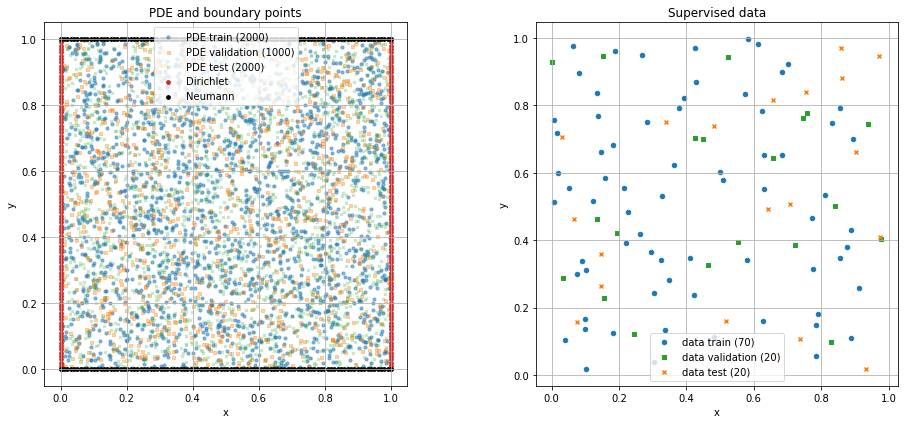

In [12]:
plot_points()


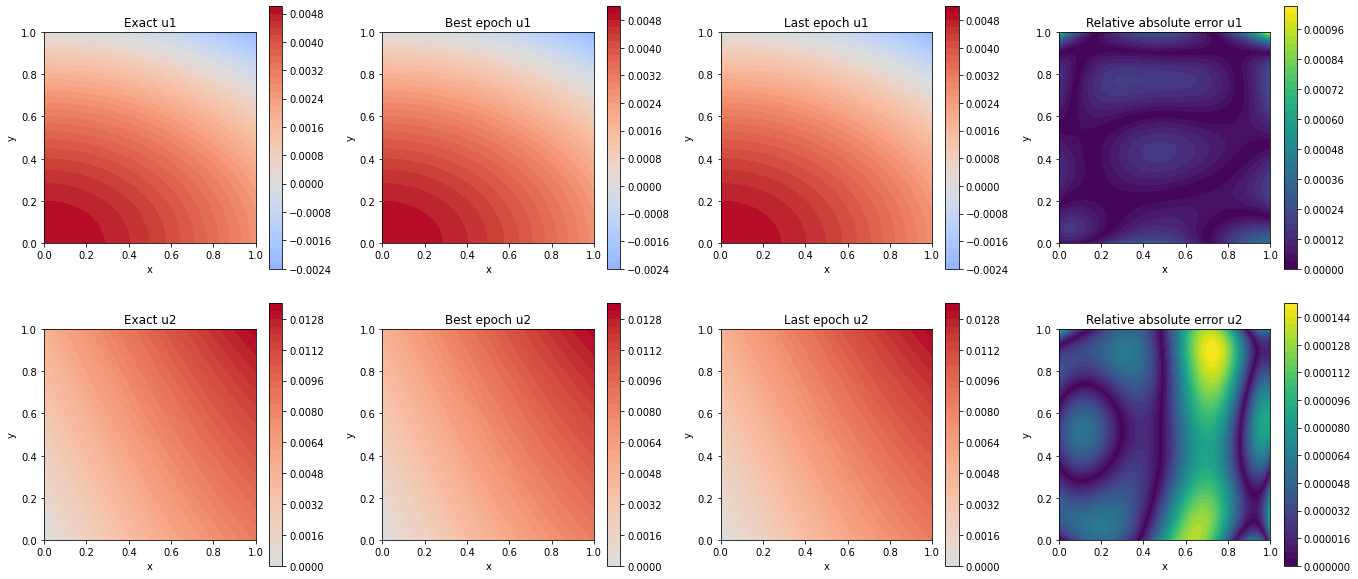

In [13]:
plot_displacement()


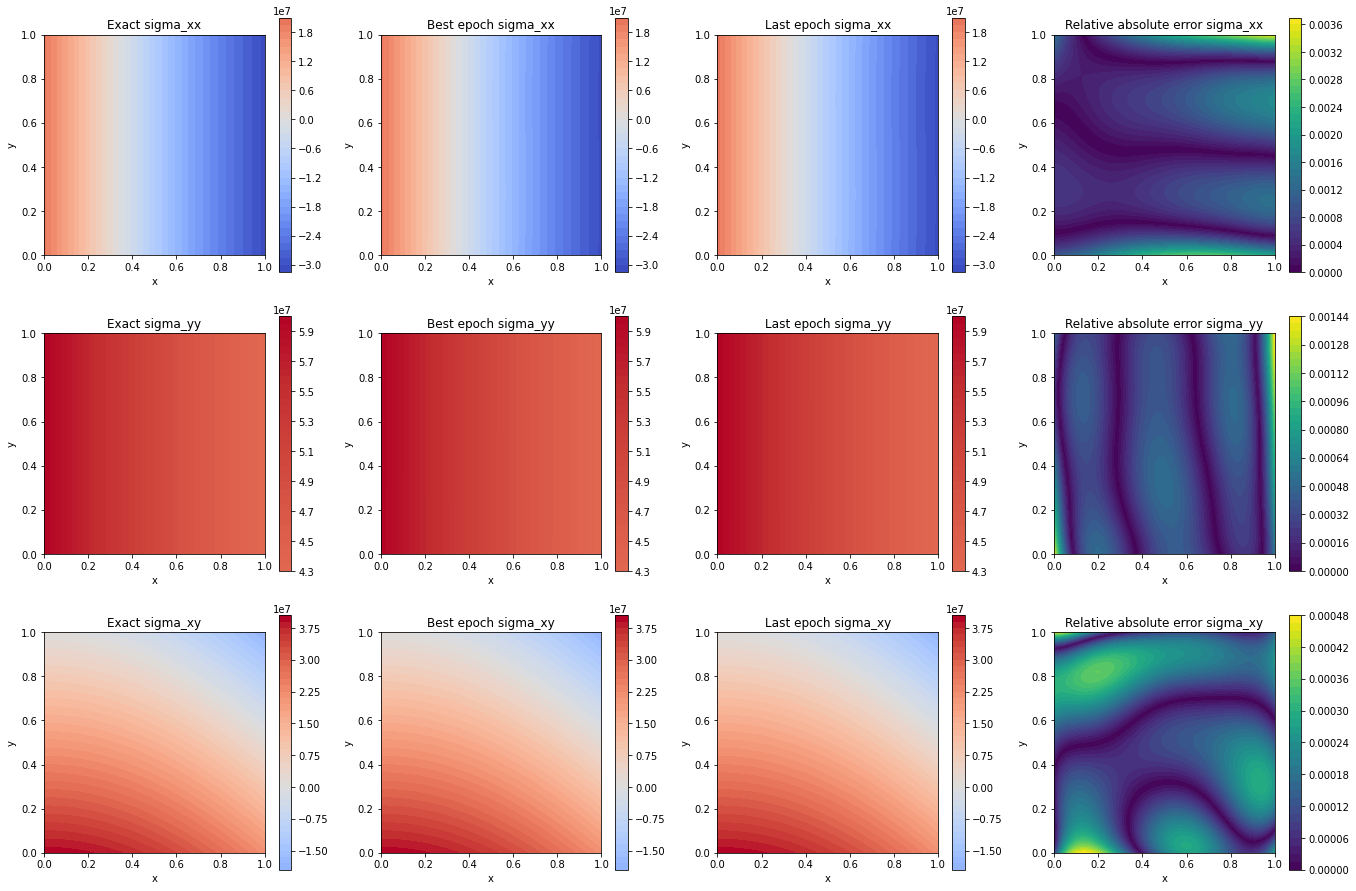

In [14]:
plot_stress()


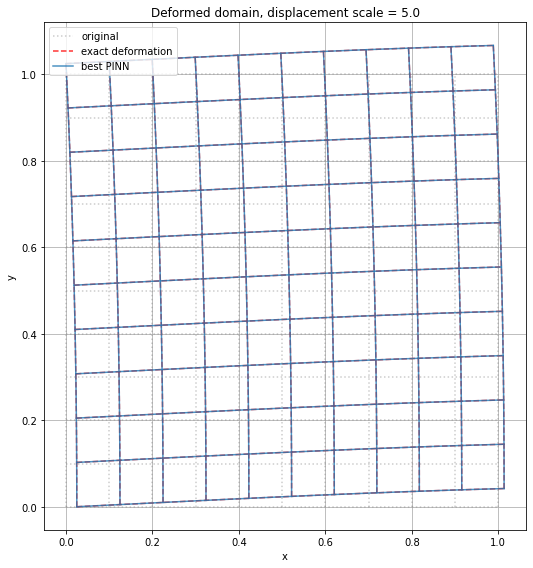

In [15]:
plot_deformed_domain(scale=5.0)


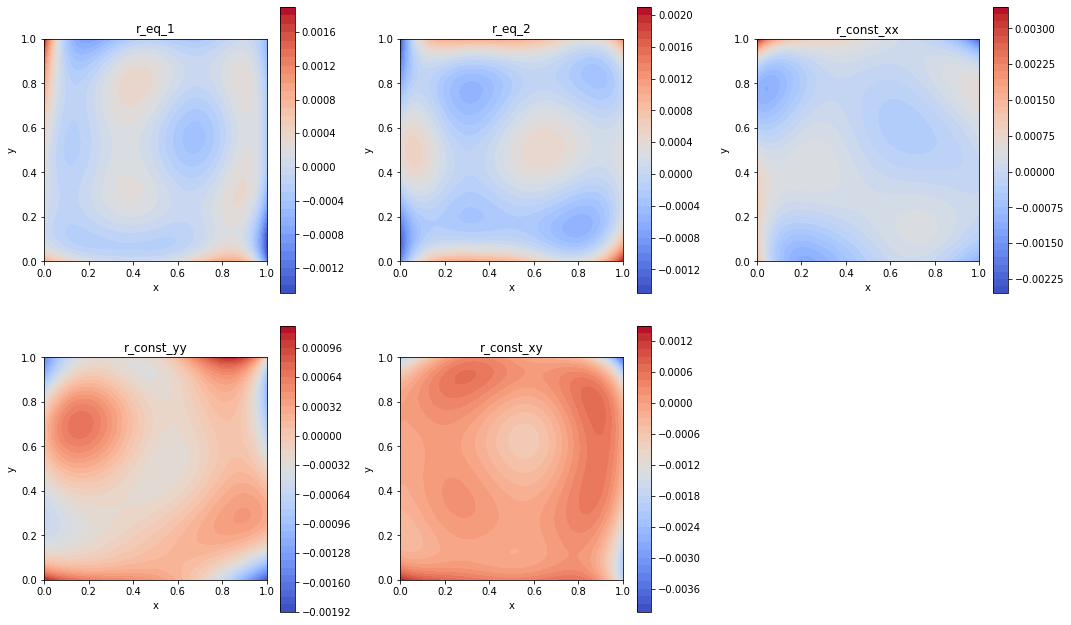

In [16]:
plot_residuals()


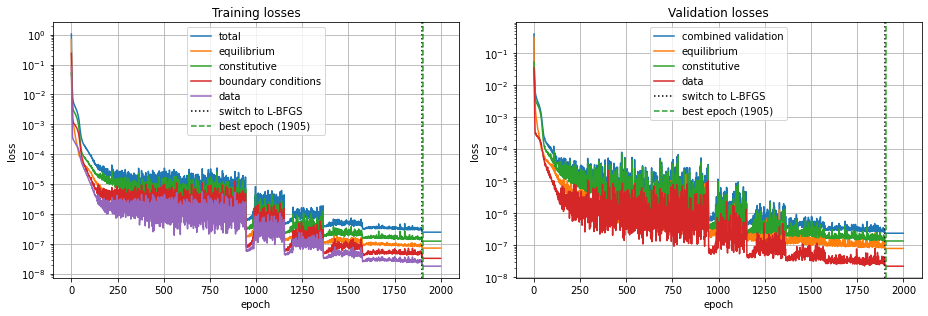

In [17]:
plot_loss()
